In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('food_ordering_behavior_dataset.csv')

print("Data loaded! Total rows:", len(df))
print("Columns:", df.columns.tolist())
df.head()

Data loaded! Total rows: 50000
Columns: ['order_id', 'user_id', 'age', 'city', 'order_time', 'day_type', 'cuisine', 'meal_type', 'restaurant_type', 'order_value', 'discount_applied', 'delivery_fee', 'time_taken_to_order', 'rating_given', 'is_repeat_order', 'mood', 'hunger_level', 'company', 'rainy_weather']


,order_id,user_id,age,city,order_time,day_type,cuisine,meal_type,restaurant_type,order_value,discount_applied,delivery_fee,time_taken_to_order,rating_given,is_repeat_order,mood,hunger_level,company,rainy_weather
0,1,2698,35,Pune,Evening,Weekend,Chinese,Dinner,Premium,971,Yes,90,13,1,Yes,Celebrating,High,Partner,No
1,2,3237,44,Mumbai,Night,Weekend,South Indian,Dinner,Budget,442,No,26,13,2,No,Lazy,Low,Family,No
2,3,3626,31,Delhi,Morning,Weekend,Biryani,Breakfast,Mid-range,739,Yes,85,10,2,Yes,Happy,Medium,Friends,No
3,4,3176,23,Delhi,Evening,Weekend,Biryani,Snacks,Mid-range,466,No,44,12,2,No,Happy,Medium,Alone,No
4,5,4824,26,Chandigarh,Morning,Weekday,Chinese,Lunch,Premium,927,Yes,58,13,2,No,Happy,Medium,Partner,Yes


In [3]:
# =============================================================
# STEP 1: DATA QUALITY CHECK
# Checking for missing values and basic statistics
# before we start any analysis
# =============================================================

print("Missing values in each column:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df[['order_value', 'delivery_fee', 'rating_given']].describe().round(2)

Missing values in each column:
order_id               0
user_id                0
age                    0
city                   0
order_time             0
day_type               0
cuisine                0
meal_type              0
restaurant_type        0
order_value            0
discount_applied       0
delivery_fee           0
time_taken_to_order    0
rating_given           0
is_repeat_order        0
mood                   0
hunger_level           0
company                0
rainy_weather          0
dtype: int64

Basic Statistics:


,order_value,delivery_fee,rating_given
count,50000.00,50000.00,50000.00
mean,547.73,59.64,2.99
std,259.69,23.04,1.41
min,100.00,20.00,1.00
25%,323.00,40.00,2.00
50%,547.00,60.00,3.00
75%,772.00,80.00,4.00
max,999.00,99.00,5.00


City Analysis:
            Total_Orders  Avg_Order_Value  Avg_Delivery_Fee  Avg_Rating
city                                                                   
Mumbai              8443           549.61             59.75        3.01
Pune                8354           552.58             59.49        2.99
Bangalore           8353           543.48             59.63        3.00
Delhi               8309           546.00             59.56        2.98
Chandigarh          8279           546.64             59.77        2.99
Hyderabad           8262           548.05             59.66        3.00


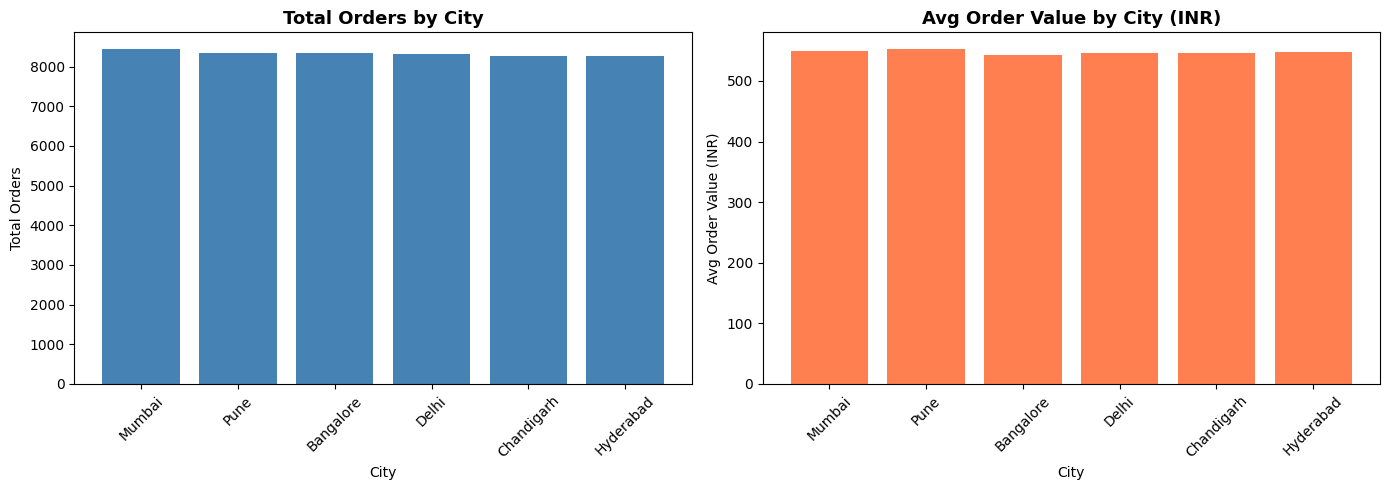


Best city for cloud kitchen:
Highest orders: Mumbai
Highest spending: Pune


In [4]:
# =============================================================
# Q1: WHICH CITY IS BEST TO OPEN A CLOUD KITCHEN?
# Analyzing order volume + avg order value per city
# High volume + high spending = best location
# =============================================================

city_analysis = df.groupby('city').agg(
    Total_Orders=('order_id', 'count'),
    Avg_Order_Value=('order_value', 'mean'),
    Avg_Delivery_Fee=('delivery_fee', 'mean'),
    Avg_Rating=('rating_given', 'mean')
).round(2).sort_values('Total_Orders', ascending=False)

print("City Analysis:")
print(city_analysis)

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Orders per city
axes[0].bar(city_analysis.index, city_analysis['Total_Orders'],
            color='steelblue')
axes[0].set_title('Total Orders by City', fontsize=13, fontweight='bold')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Total Orders')
axes[0].tick_params(axis='x', rotation=45)

# Avg order value per city
axes[1].bar(city_analysis.index, city_analysis['Avg_Order_Value'],
            color='coral')
axes[1].set_title('Avg Order Value by City (INR)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Avg Order Value (INR)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('q1_city_analysis.png', dpi=150)
plt.show()

print("\nBest city for cloud kitchen:")
best_city = city_analysis['Total_Orders'].idxmax()
print(f"Highest orders: {best_city}")
best_value = city_analysis['Avg_Order_Value'].idxmax()
print(f"Highest spending: {best_value}")

Orders by Time of Day:
            Total_Orders  Avg_Order_Value  Avg_Rating
order_time                                           
Morning            12524           545.77        3.01
Afternoon          12413           549.13        2.98
Evening            12550           550.13        3.00
Night              12513           545.90        2.99


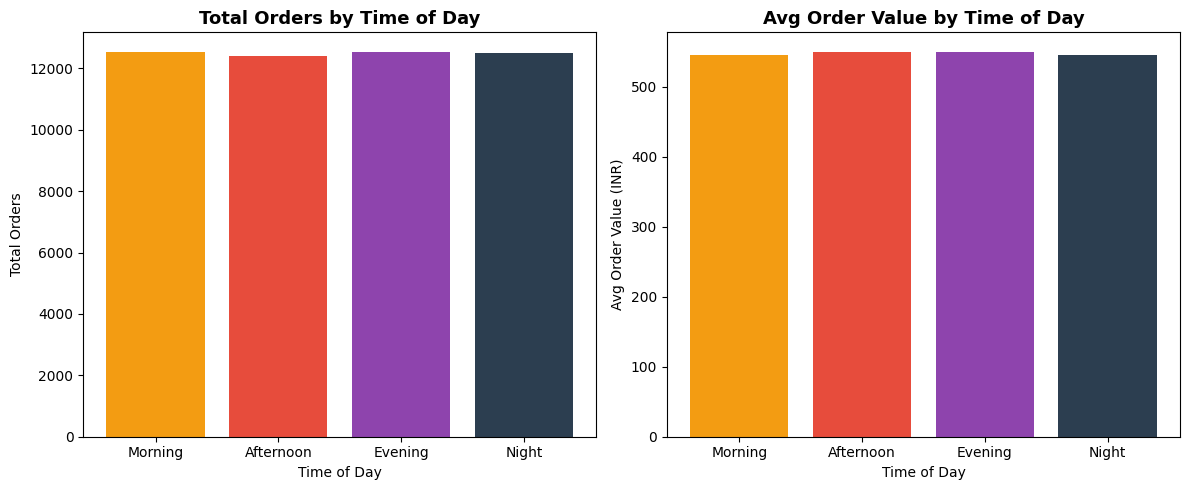


Peak ordering time:
Evening

Highest spending time:
Evening


In [5]:
# =============================================================
# Q2: WHAT TIME OF DAY HAS MOST ORDERS?
# This tells us the OPERATING HOURS for our cloud kitchen
# =============================================================

time_analysis = df.groupby('order_time').agg(
    Total_Orders=('order_id', 'count'),
    Avg_Order_Value=('order_value', 'mean'),
    Avg_Rating=('rating_given', 'mean')
).round(2)

# Define correct time order
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
time_analysis = time_analysis.reindex(time_order)

print("Orders by Time of Day:")
print(time_analysis)

# Chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Orders by time
axes[0].bar(time_analysis.index, time_analysis['Total_Orders'],
            color=['#f39c12','#e74c3c','#8e44ad','#2c3e50'])
axes[0].set_title('Total Orders by Time of Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Time of Day')
axes[0].set_ylabel('Total Orders')

# Avg order value by time
axes[1].bar(time_analysis.index, time_analysis['Avg_Order_Value'],
            color=['#f39c12','#e74c3c','#8e44ad','#2c3e50'])
axes[1].set_title('Avg Order Value by Time of Day', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Time of Day')
axes[1].set_ylabel('Avg Order Value (INR)')

plt.tight_layout()
plt.savefig('q2_time_analysis.png', dpi=150)
plt.show()

print("\nPeak ordering time:")
print(time_analysis['Total_Orders'].idxmax())
print("\nHighest spending time:")
print(time_analysis['Avg_Order_Value'].idxmax())

Cuisine Analysis:
              Total_Orders  Avg_Order_Value  Avg_Rating  Repeat_Order_Rate
cuisine                                                                   
Desserts              8452           547.47        3.00              50.22
Fast Food             8368           548.85        2.99              50.57
Chinese               8351           548.59        3.00              49.49
South Indian          8301           552.08        3.00              49.87
Biryani               8300           546.48        2.98              50.39
North Indian          8228           542.88        3.00              49.27


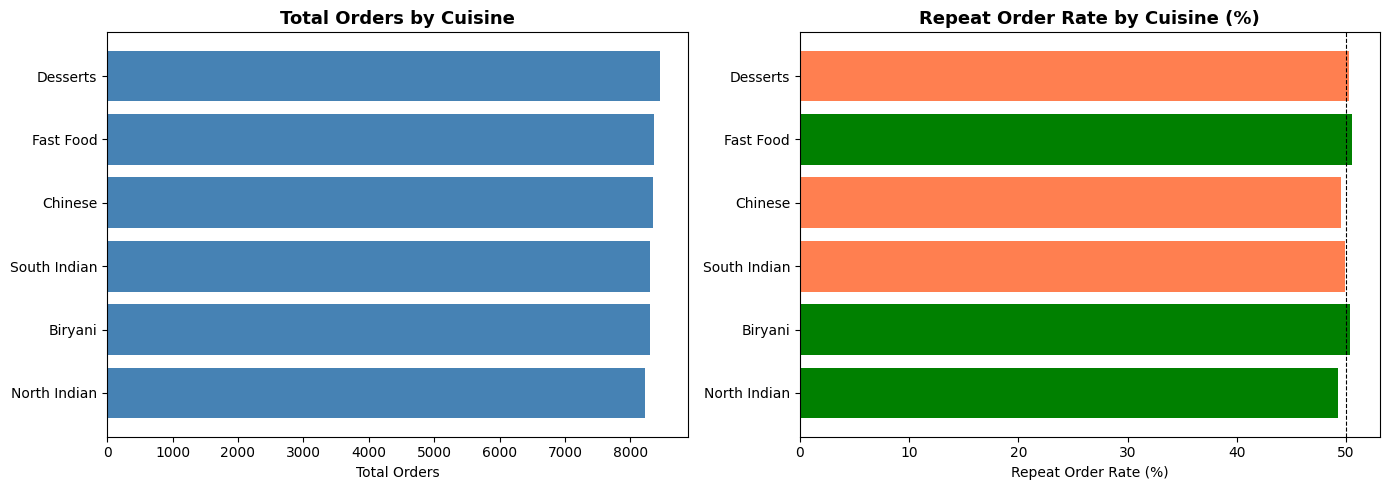


Most ordered cuisine: Desserts
Highest repeat rate: Fast Food
Highest avg value: South Indian


In [6]:
# =============================================================
# Q3: WHICH CUISINE SHOULD OUR CLOUD KITCHEN SERVE?
# Most ordered cuisine = safest menu choice
# Highest rated cuisine = best quality opportunity
# =============================================================

cuisine_analysis = df.groupby('cuisine').agg(
    Total_Orders=('order_id', 'count'),
    Avg_Order_Value=('order_value', 'mean'),
    Avg_Rating=('rating_given', 'mean'),
    Repeat_Order_Rate=('is_repeat_order', lambda x: 
                       (x=='Yes').sum()/len(x)*100)
).round(2).sort_values('Total_Orders', ascending=False)

print("Cuisine Analysis:")
print(cuisine_analysis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total orders by cuisine
axes[0].barh(cuisine_analysis.index[::-1], 
             cuisine_analysis['Total_Orders'][::-1],
             color='steelblue')
axes[0].set_title('Total Orders by Cuisine', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Orders')

# Repeat order rate by cuisine
colors = ['green' if x > 50 else 'coral' 
          for x in cuisine_analysis['Repeat_Order_Rate']]
axes[1].barh(cuisine_analysis.index[::-1],
             cuisine_analysis['Repeat_Order_Rate'][::-1],
             color=colors)
axes[1].set_title('Repeat Order Rate by Cuisine (%)', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Repeat Order Rate (%)')
axes[1].axvline(x=50, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('q3_cuisine_analysis.png', dpi=150)
plt.show()

print("\nMost ordered cuisine:", cuisine_analysis['Total_Orders'].idxmax())
print("Highest repeat rate:", cuisine_analysis['Repeat_Order_Rate'].idxmax())
print("Highest avg value:", cuisine_analysis['Avg_Order_Value'].idxmax())

Discount Impact Analysis:
                  Total_Orders  Avg_Order_Value  Avg_Delivery_Fee  Avg_Rating  \
discount_applied                                                                
No                       24883           549.16             59.45        2.99   
Yes                      25117           546.31             59.83        3.00   

                  Repeat_Rate  
discount_applied               
No                      49.98  
Yes                     49.96  


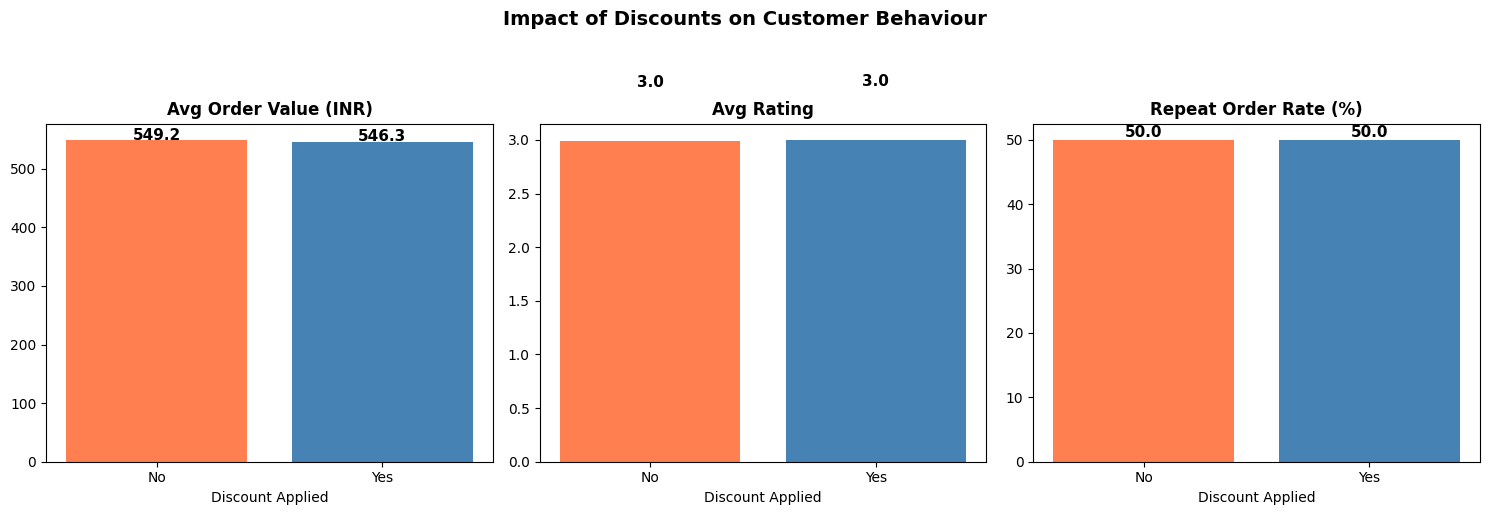


Does discount increase repeat orders?
With discount repeat rate: 49.96%
Without discount repeat rate: 49.98%
Difference: -0.02%


In [7]:
# =============================================================
# Q4: DOES DISCOUNT DRIVE REPEAT ORDERS?
# This tells us our discount strategy
# Should we offer discounts or focus on quality?
# =============================================================

discount_analysis = df.groupby('discount_applied').agg(
    Total_Orders=('order_id', 'count'),
    Avg_Order_Value=('order_value', 'mean'),
    Avg_Delivery_Fee=('delivery_fee', 'mean'),
    Avg_Rating=('rating_given', 'mean'),
    Repeat_Rate=('is_repeat_order', lambda x: 
                 (x=='Yes').sum()/len(x)*100)
).round(2)

print("Discount Impact Analysis:")
print(discount_analysis)

# Chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Avg_Order_Value', 'Avg_Rating', 'Repeat_Rate']
titles = ['Avg Order Value (INR)', 'Avg Rating', 'Repeat Order Rate (%)']
colors = [['coral', 'steelblue'], ['coral', 'steelblue'], ['coral', 'steelblue']]

for i, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    axes[i].bar(discount_analysis.index, discount_analysis[metric],
                color=color)
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Discount Applied')
    for bar, val in zip(axes[i].patches, discount_analysis[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.5,
                    f'{val:.1f}', ha='center', fontsize=11,
                    fontweight='bold')

plt.suptitle('Impact of Discounts on Customer Behaviour',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q4_discount_analysis.png', dpi=150)
plt.show()

print("\nDoes discount increase repeat orders?")
no_disc = discount_analysis.loc['No', 'Repeat_Rate']
yes_disc = discount_analysis.loc['Yes', 'Repeat_Rate']
diff = yes_disc - no_disc
print(f"With discount repeat rate: {yes_disc}%")
print(f"Without discount repeat rate: {no_disc}%")
print(f"Difference: {diff:.2f}%")

Restaurant Type Analysis:
                 Total_Orders  Avg_Order_Value  Avg_Rating  Repeat_Rate  \
restaurant_type                                                           
Premium                 16859           549.20        3.01        50.15   
Budget                  16660           548.54        2.99        49.56   
Mid-range               16481           545.41        2.98        50.22   

                 Avg_Delivery_Fee  
restaurant_type                    
Premium                     59.68  
Budget                      59.54  
Mid-range                   59.71  


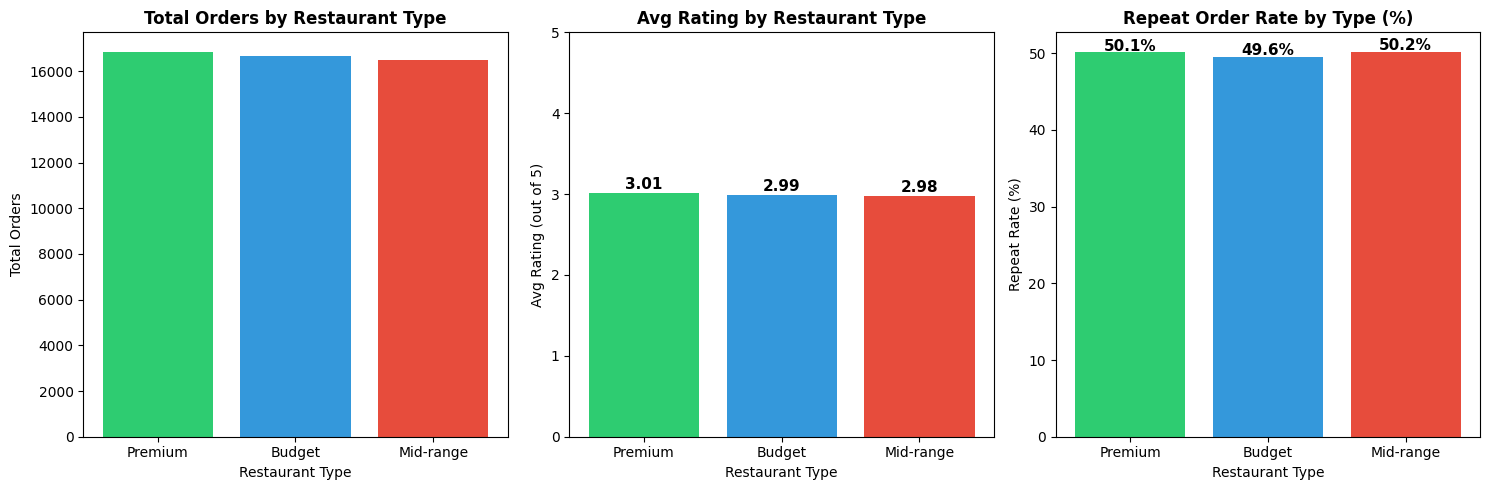


Best restaurant type by rating: Premium
Best restaurant type by repeat rate: Mid-range


In [8]:
# =============================================================
# Q5: BUDGET VS PREMIUM — WHICH RESTAURANT TYPE WINS?
# This decides our cloud kitchen positioning
# Should we be budget, mid-range or premium?
# =============================================================

restaurant_analysis = df.groupby('restaurant_type').agg(
    Total_Orders=('order_id', 'count'),
    Avg_Order_Value=('order_value', 'mean'),
    Avg_Rating=('rating_given', 'mean'),
    Repeat_Rate=('is_repeat_order', lambda x:
                 (x=='Yes').sum()/len(x)*100),
    Avg_Delivery_Fee=('delivery_fee', 'mean')
).round(2).sort_values('Avg_Rating', ascending=False)

print("Restaurant Type Analysis:")
print(restaurant_analysis)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Orders
axes[0].bar(restaurant_analysis.index,
            restaurant_analysis['Total_Orders'],
            color=['#2ecc71','#3498db','#e74c3c'])
axes[0].set_title('Total Orders by Restaurant Type',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Restaurant Type')
axes[0].set_ylabel('Total Orders')

# Rating
axes[1].bar(restaurant_analysis.index,
            restaurant_analysis['Avg_Rating'],
            color=['#2ecc71','#3498db','#e74c3c'])
axes[1].set_title('Avg Rating by Restaurant Type',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Restaurant Type')
axes[1].set_ylabel('Avg Rating (out of 5)')
axes[1].set_ylim(0, 5)
for bar, val in zip(axes[1].patches, restaurant_analysis['Avg_Rating']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.05,
                f'{val:.2f}', ha='center',
                fontsize=11, fontweight='bold')

# Repeat rate
axes[2].bar(restaurant_analysis.index,
            restaurant_analysis['Repeat_Rate'],
            color=['#2ecc71','#3498db','#e74c3c'])
axes[2].set_title('Repeat Order Rate by Type (%)',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Restaurant Type')
axes[2].set_ylabel('Repeat Rate (%)')
for bar, val in zip(axes[2].patches, restaurant_analysis['Repeat_Rate']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('q5_restaurant_type.png', dpi=150)
plt.show()

print("\nBest restaurant type by rating:",
      restaurant_analysis['Avg_Rating'].idxmax())
print("Best restaurant type by repeat rate:",
      restaurant_analysis['Repeat_Rate'].idxmax())

Top 10 Mood + Hunger Combos by Order Value:
                          Total_Orders  Avg_Order_Value  Avg_Rating
mood        hunger_level                                           
Lazy        Low                   4107           553.71        2.97
            Medium                4029           552.54        3.00
Happy       High                  4207           552.11        2.98
Stressed    High                  4232           551.84        3.03
Celebrating High                  4132           548.72        2.98
            Low                   4266           548.24        3.00
Stressed    Medium                4319           547.61        3.03
Lazy        High                  4147           545.27        2.98
Celebrating Medium                4182           545.20        3.01
Stressed    Low                   4121           543.21        2.99

Avg Order Value by Mood and Hunger Level:
hunger_level    High     Low  Medium
mood                                
Celebrating   548.72  5

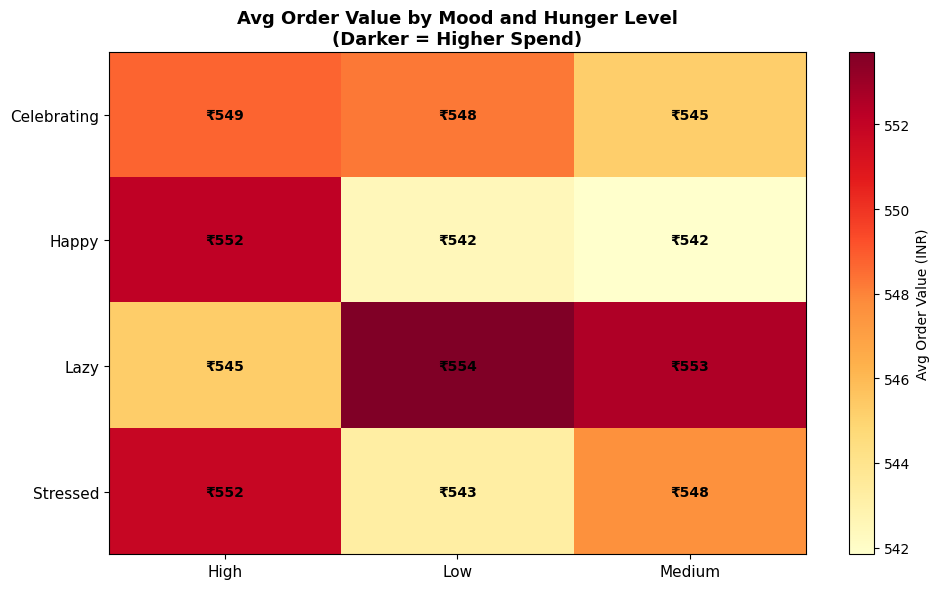

In [9]:
# =============================================================
# BONUS Q1: WHEN ARE CUSTOMERS MOST DESPERATE TO ORDER?
# Mood + Hunger Level combo = highest order value
# This tells us WHEN to push marketing notifications
# =============================================================

mood_hunger = df.groupby(['mood', 'hunger_level']).agg(
    Total_Orders=('order_id', 'count'),
    Avg_Order_Value=('order_value', 'mean'),
    Avg_Rating=('rating_given', 'mean')
).round(2).sort_values('Avg_Order_Value', ascending=False)

print("Top 10 Mood + Hunger Combos by Order Value:")
print(mood_hunger.head(10))

# Pivot for heatmap
pivot = df.pivot_table(
    values='order_value',
    index='mood',
    columns='hunger_level',
    aggfunc='mean'
).round(2)

print("\nAvg Order Value by Mood and Hunger Level:")
print(pivot)

plt.figure(figsize=(10, 6))
im = plt.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, label='Avg Order Value (INR)')
plt.xticks(range(len(pivot.columns)), pivot.columns, fontsize=11)
plt.yticks(range(len(pivot.index)), pivot.index, fontsize=11)
plt.title('Avg Order Value by Mood and Hunger Level\n(Darker = Higher Spend)',
          fontsize=13, fontweight='bold')

# Add values inside heatmap
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        plt.text(j, i, f'₹{pivot.values[i][j]:.0f}',
                ha='center', va='center',
                fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('bonus_mood_hunger.png', dpi=150)
plt.show()

Rain Impact Analysis:
               Total_Orders  Avg_Order_Value  Avg_Rating  Avg_Delivery_Fee  \
rainy_weather                                                                
No                    25007           549.58        2.99             59.76   
Yes                   24993           545.88        3.00             59.52   

               Repeat_Rate  
rainy_weather               
No                   50.02  
Yes                  49.92  

Most ordered cuisines on rainy days:
              Orders
cuisine             
Fast Food       4237
Chinese         4178
Biryani         4159
South Indian    4159
North Indian    4153
Desserts        4107


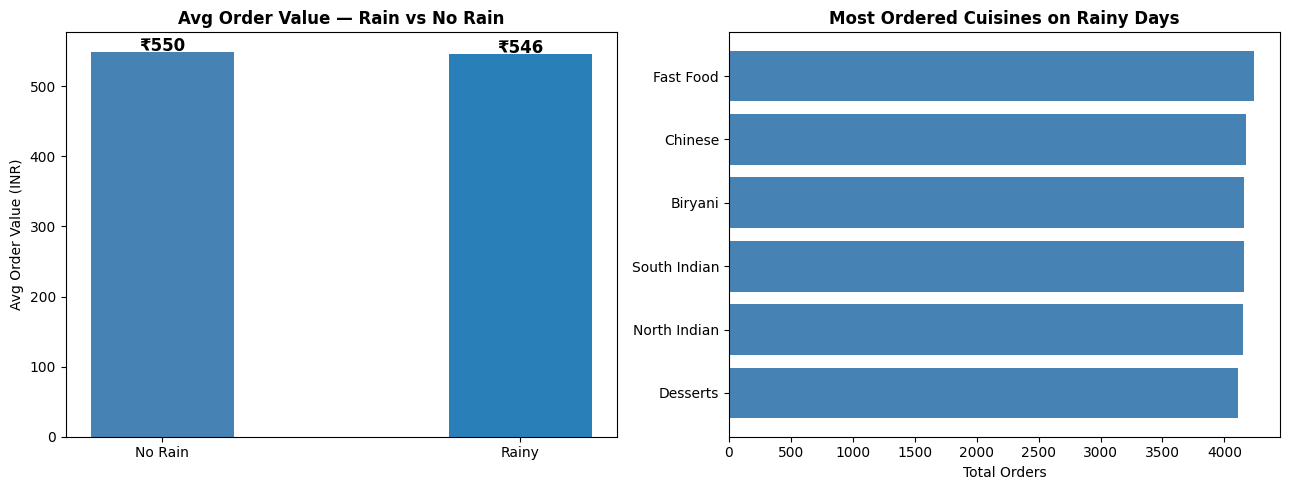


Does rain increase avg order value?
No rain avg: ₹549.58
Rainy avg: ₹545.88
Difference: ₹-3.70


In [10]:
# =============================================================
# BONUS Q2: DO RAINY DAYS INCREASE ORDERS AND SPENDING?
# This tells us weather-based marketing strategy
# Should we push notifications when it rains?
# =============================================================

rain_analysis = df.groupby('rainy_weather').agg(
    Total_Orders=('order_id', 'count'),
    Avg_Order_Value=('order_value', 'mean'),
    Avg_Rating=('rating_given', 'mean'),
    Avg_Delivery_Fee=('delivery_fee', 'mean'),
    Repeat_Rate=('is_repeat_order', lambda x:
                 (x=='Yes').sum()/len(x)*100)
).round(2)

print("Rain Impact Analysis:")
print(rain_analysis)

# Also check cuisine preference on rainy days
rainy_cuisine = df[df['rainy_weather']=='Yes'].groupby('cuisine').agg(
    Orders=('order_id','count')
).sort_values('Orders', ascending=False)

print("\nMost ordered cuisines on rainy days:")
print(rainy_cuisine)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Rain vs no rain
metrics = ['Avg_Order_Value', 'Repeat_Rate']
axes[0].bar(['No Rain', 'Rainy'],
            rain_analysis['Avg_Order_Value'],
            color=['steelblue', '#2980b9'], width=0.4)
axes[0].set_title('Avg Order Value — Rain vs No Rain',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg Order Value (INR)')
for bar, val in zip(axes[0].patches, rain_analysis['Avg_Order_Value']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'₹{val:.0f}', ha='center',
                fontsize=12, fontweight='bold')

# Rainy day cuisine
axes[1].barh(rainy_cuisine.index[::-1],
             rainy_cuisine['Orders'][::-1],
             color='steelblue')
axes[1].set_title('Most Ordered Cuisines on Rainy Days',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Orders')

plt.tight_layout()
plt.savefig('bonus_rain_analysis.png', dpi=150)
plt.show()

print("\nDoes rain increase avg order value?")
no_rain = rain_analysis.loc['No', 'Avg_Order_Value']
yes_rain = rain_analysis.loc['Yes', 'Avg_Order_Value']
print(f"No rain avg: ₹{no_rain}")
print(f"Rainy avg: ₹{yes_rain}")
print(f"Difference: ₹{yes_rain - no_rain:.2f}")

Delivery Fee vs Order Value Analysis:
                 Avg_Delivery_Fee  Avg_Order_Value  Total_Orders  Repeat_Rate
restaurant_type                                                              
Budget                      59.54           548.54         16660        49.56
Mid-range                   59.71           545.41         16481        50.22
Premium                     59.68           549.20         16859        50.15

Spending by Age Group:
                      Total_Orders  Avg_Order_Value  Avg_Rating  Repeat_Rate
age_group                                                                   
18-25\n(Students)            12909           544.01        3.00        49.35
26-35\n(IT/Working)          18614           546.57        3.00        49.74
36-45\n(Senior Prof)         16577           551.99        2.98        50.78

Weekday vs Weekend:
          Total_Orders  Avg_Order_Value  Avg_Rating
day_type                                           
Weekday          24958           549.2

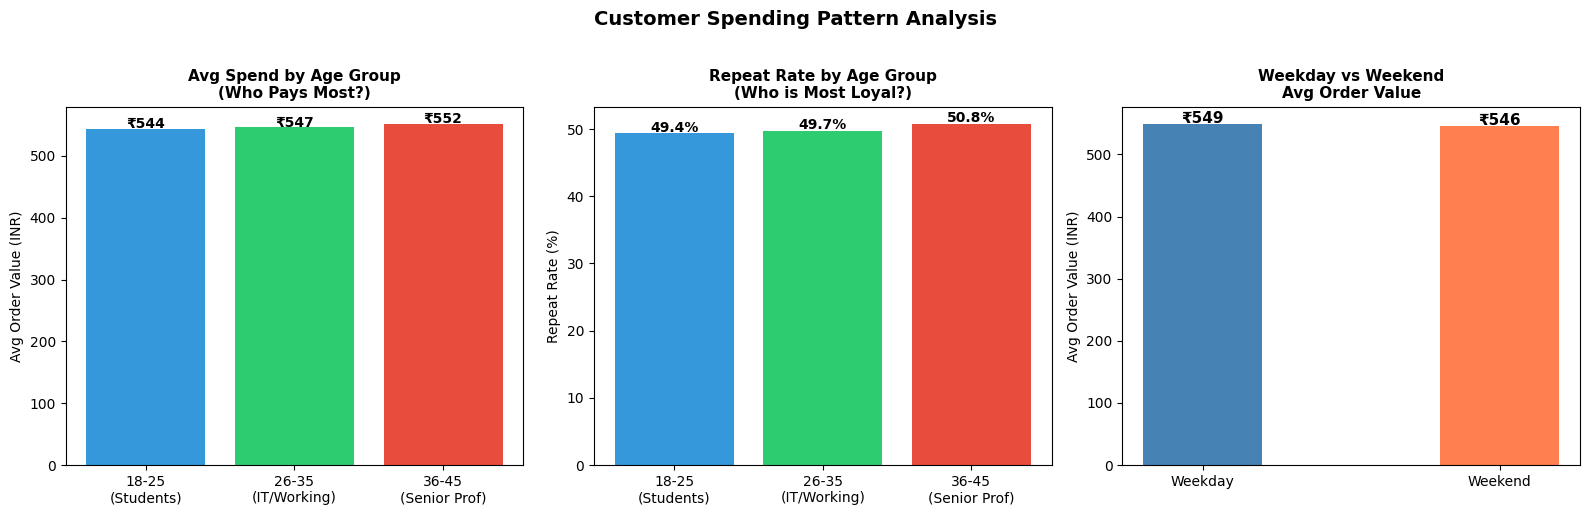

In [11]:
# =============================================================
# ADVANCED ANALYSIS: CUSTOMER WILLINGNESS TO PAY
# Analyzing spending patterns to build location-specific
# pricing strategy for our cloud kitchen network
# =============================================================

# Delivery fee sensitivity — how much are customers paying?
delivery_analysis = df.groupby('restaurant_type').agg(
    Avg_Delivery_Fee=('delivery_fee', 'mean'),
    Avg_Order_Value=('order_value', 'mean'),
    Total_Orders=('order_id', 'count'),
    Repeat_Rate=('is_repeat_order', lambda x:
                 (x=='Yes').sum()/len(x)*100)
).round(2)

print("Delivery Fee vs Order Value Analysis:")
print(delivery_analysis)

# Age group analysis — who spends most?
df['age_group'] = pd.cut(df['age'],
                          bins=[18, 25, 35, 45, 60],
                          labels=['18-25\n(Students)',
                                  '26-35\n(IT/Working)',
                                  '36-45\n(Senior Prof)',
                                  '46-60\n(Family)'])

age_analysis = df.groupby('age_group', observed=True).agg(
    Total_Orders=('order_id', 'count'),
    Avg_Order_Value=('order_value', 'mean'),
    Avg_Rating=('rating_given', 'mean'),
    Repeat_Rate=('is_repeat_order', lambda x:
                 (x=='Yes').sum()/len(x)*100)
).round(2)

print("\nSpending by Age Group:")
print(age_analysis)

# Weekday vs Weekend spending
day_analysis = df.groupby('day_type').agg(
    Total_Orders=('order_id', 'count'),
    Avg_Order_Value=('order_value', 'mean'),
    Avg_Rating=('rating_given', 'mean')
).round(2)

print("\nWeekday vs Weekend:")
print(day_analysis)

# Chart — 3 insights in one figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age group spending
axes[0].bar(age_analysis.index,
            age_analysis['Avg_Order_Value'],
            color=['#3498db','#2ecc71','#e74c3c','#f39c12'])
axes[0].set_title('Avg Spend by Age Group\n(Who Pays Most?)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Avg Order Value (INR)')
for bar, val in zip(axes[0].patches,
                    age_analysis['Avg_Order_Value']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'₹{val:.0f}', ha='center',
                fontsize=10, fontweight='bold')

# Repeat rate by age
axes[1].bar(age_analysis.index,
            age_analysis['Repeat_Rate'],
            color=['#3498db','#2ecc71','#e74c3c','#f39c12'])
axes[1].set_title('Repeat Rate by Age Group\n(Who is Most Loyal?)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Repeat Rate (%)')
for bar, val in zip(axes[1].patches,
                    age_analysis['Repeat_Rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center',
                fontsize=10, fontweight='bold')

# Weekday vs weekend
axes[2].bar(day_analysis.index,
            day_analysis['Avg_Order_Value'],
            color=['steelblue', 'coral'],
            width=0.4)
axes[2].set_title('Weekday vs Weekend\nAvg Order Value',
                  fontsize=11, fontweight='bold')
axes[2].set_ylabel('Avg Order Value (INR)')
for bar, val in zip(axes[2].patches,
                    day_analysis['Avg_Order_Value']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'₹{val:.0f}', ha='center',
                fontsize=11, fontweight='bold')

plt.suptitle('Customer Spending Pattern Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('advanced_spending_analysis.png', dpi=150)
plt.show()